## Importing Libraries and Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

In [ ]:
df = pd.read_json('../data/intent-detection-train.jsonl', lines=True)

df.head()

,text,label
0,Pouvez-vous me dire comment dire «je ne parle ...,translate
1,Dites-moi comment dire: «C'est une belle matin...,translate
2,"Si j'étais japonais, comment dirais-je que je ...",translate
3,Comment dire «hôtel» en finnois,translate
4,"J'ai besoin que vous traduisiez la phrase, «no...",translate


## Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    75 non-null     object
 1   label   75 non-null     object
dtypes: object(2)
memory usage: 1.3+ KB


In [4]:
print("Number of NaNs : " , df.isna().sum().sum())
print("Number of duplicate rows: : ", df.duplicated().sum())

Number of NaNs :  0
Number of duplicate rows: :  0


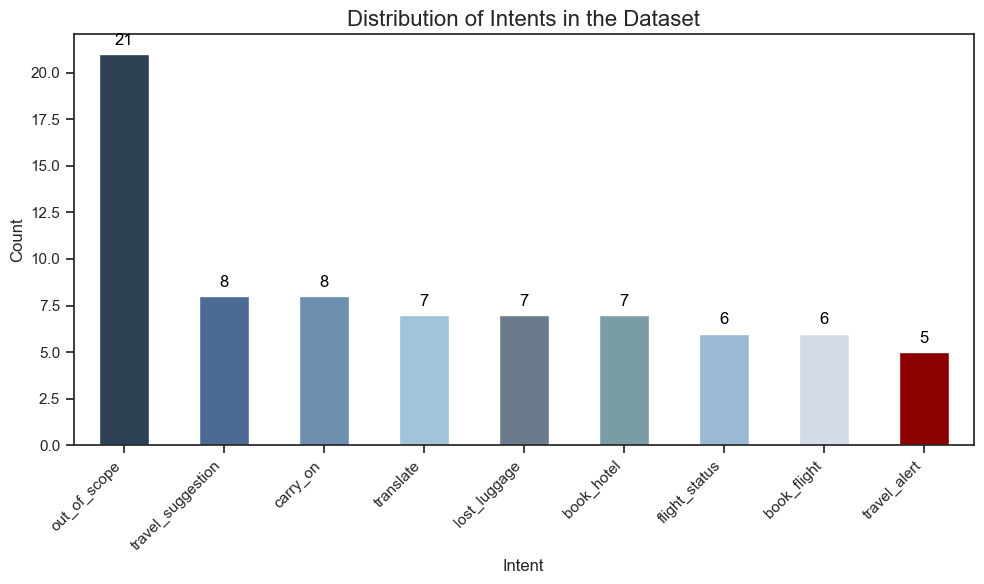

In [5]:
sns.set(style="ticks") 

colors = ['#2E4053', '#4C6A92', '#6C8EAF', '#A1C4D8', '#6C7B8B', '#7A9CA5', '#9BB9D2', '#D3DCE6', '#8B0000']


plt.figure(figsize=(10, 6))  
ax = df['label'].value_counts().plot(kind='bar', color=colors)

plt.title('Distribution of Intents in the Dataset', fontsize=16)
plt.xlabel('Intent', fontsize=12)
plt.ylabel('Count', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=12, color='black', 
                xytext=(0, 10), 
                textcoords='offset points')

plt.xticks(rotation=45, ha="right")  
plt.tight_layout()  
plt.show()

## Data experiments for next steps

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

rows = len(df)
intents = df['label'].nunique()
counts = df['label'].value_counts()
chars = df['text'].str.len()
tokens = df['text'].str.split().str.len()

summary = pd.DataFrame({
    'rows': [rows],
    'intents': [intents],
    'avg_samples_per_intent': [counts.mean()],
    'min_samples_per_intent': [counts.min()],
    'max_samples_per_intent': [counts.max()],
    'duplicate_rate': [df.duplicated().mean()],
    'avg_chars': [chars.mean()],
    'avg_tokens': [tokens.mean()],
})
summary

,rows,intents,avg_samples_per_intent,min_samples_per_intent,max_samples_per_intent,duplicate_rate,avg_chars,avg_tokens
0,75,9,8.333333,5,21,0.0,54.24,9.386667


In [8]:
from sklearn.metrics.pairwise import cosine_similarity

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])

sim_matrix = cosine_similarity(X_test, X_train)
max_sim = sim_matrix.max(axis=1)

pd.Series(max_sim).describe()

count    15.000000
mean      0.425149
std       0.165920
min       0.154518
25%       0.343752
50%       0.390252
75%       0.509534
max       0.777418
dtype: float64

In [9]:
baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

X = df['text']
y = df['label']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(baseline_pipeline, X, y, cv=cv, scoring='f1_macro')

pd.DataFrame({
    'f1_macro_mean': [scores.mean()],
    'f1_macro_std': [scores.std()],
    'fold_scores': [scores.tolist()]
})

,f1_macro_mean,f1_macro_std,fold_scores
0,0.667037,0.095167,"[0.7555555555555555, 0.7388888888888889, 0.703..."


In [10]:
import re

def perturb_text(text: str) -> list[str]:
    variants = set()
    variants.add(text)
    variants.add(text.lower())
    variants.add(text.upper())
    variants.add(re.sub(r'\s+', ' ', text).strip())
    variants.add(text.replace("'", " "))
    variants.add(text + " !!!")
    variants.add(text + " svp")
    variants.add(text + " urgent")

    typo_variant = re.sub(r'([aeiou])', r'\1\1', text, count=1, flags=re.IGNORECASE)
    variants.add(typo_variant)

    return [v for v in variants if isinstance(v, str) and len(v.strip()) > 0]

rows = []
for _, row in df.iterrows():
    for variant in perturb_text(str(row['text'])):
        rows.append({'text': variant, 'label': row['label'], 'source': 'rule_perturb'})

stress_df = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)
stress_df.shape

(548, 3)

In [ ]:
stress_path = '../data/intent-detection-test-perturbed.jsonl'
stress_df.to_json(stress_path, orient='records', lines=True, force_ascii=False)
stress_df['label'].value_counts()

label
out_of_scope         155
carry_on              57
travel_suggestion     55
lost_luggage          54
translate             52
book_hotel            52
book_flight           44
flight_status         43
travel_alert          36
Name: count, dtype: int64